In [ ]:
# Synthetic Clinical Diagnosis Classification using MLflow

## Objective

The objective of this project is to build an end-to-end machine learning classification model using the Synthetic Clinical Tabular Dataset. 
The project follows good machine learning practices, including data preprocessing, model comparison using Stratified 5-Fold Cross-Validation, MLflow experiment tracking, model registration, inference, and model improvement.

## Machine Learning Problem

- Dataset: Synthetic Clinical Tabular Dataset
- Problem Type: Classification
- Goal: Predict the patient's diagnosis based on the available clinical features.

### Train-Test Split

The dataset was divided into **80% training data** and **20% testing data** using `train_test_split`.

- **80% Training Set:** Used to train the machine learning model.
- **20% Testing Set:** Used to evaluate the model's performance on unseen data.

This split helps assess how well the model generalizes to new clinical data while avoiding evaluation on the same data used for training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [7]:
import os

print(os.getcwd())

/Users/sunandanasahoo/synthetic-clinical-mlflow-project/notebooks


Load the Dataset

In [11]:
import pandas as pd

df = pd.read_csv("../data/synthetic_clinical_dataset.csv")
df.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,diagnosis,readmission_30d,mortality
0,1001,63,Male,24.1,131.0,81.0,136.2,210.3,1.04,0,0,Sepsis,0,0
1,1002,52,Male,20.8,118.0,91.0,136.5,207.9,1.49,0,1,Normal,0,0
2,1003,66,Male,30.0,144.0,73.0,100.0,179.5,1.15,0,0,Normal,0,0
3,1004,82,Male,16.8,112.0,76.0,117.3,228.3,0.59,0,0,Heart Failure,0,0
4,1005,50,Female,25.4,102.0,65.0,128.0,150.7,1.38,0,0,Normal,0,0


df.shape returns the dimensions of the dataset in the form (rows, columns).

In [12]:
df.shape

(10000, 14)

### Dataset Information

The `info()` function was used to obtain a summary of the dataset, including the number of records, column names, data types, and non-null values. This step helps verify the dataset structure and identify any missing values before data preprocessing.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       10000 non-null  int64  
 1   age              10000 non-null  int64  
 2   sex              10000 non-null  object 
 3   bmi              10000 non-null  float64
 4   systolic_bp      10000 non-null  float64
 5   diastolic_bp     10000 non-null  float64
 6   glucose          10000 non-null  float64
 7   cholesterol      10000 non-null  float64
 8   creatinine       10000 non-null  float64
 9   diabetes         10000 non-null  int64  
 10  hypertension     10000 non-null  int64  
 11  diagnosis        10000 non-null  object 
 12  readmission_30d  10000 non-null  int64  
 13  mortality        10000 non-null  int64  
dtypes: float64(6), int64(6), object(2)
memory usage: 1.1+ MB


### Descriptive Statistics

The `describe()` function was used to generate summary statistics for the numerical features in the dataset. It provides measures such as count, mean, standard deviation, minimum, maximum, and quartile values, helping to understand the distribution and range of the data before model training.

In [14]:
df.describe()

,patient_id,age,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6000.50000,54.299700,27.022170,124.814700,80.339200,106.009840,190.890480,1.003569,0.11920,0.304500,0.139000,0.027300
std,2886.89568,17.640232,5.832599,17.648686,11.388859,23.375168,34.329647,0.287716,0.32404,0.460218,0.345964,0.162964
min,1001.00000,0.000000,15.000000,90.000000,60.000000,70.000000,120.000000,0.500000,0.00000,0.000000,0.000000,0.000000
25%,3500.75000,42.000000,22.900000,112.000000,72.000000,88.100000,166.775000,0.790000,0.00000,0.000000,0.000000,0.000000
50%,6000.50000,54.000000,27.000000,125.000000,80.000000,105.300000,190.850000,1.000000,0.00000,0.000000,0.000000,0.000000
75%,8500.25000,67.000000,31.000000,137.000000,88.000000,122.100000,214.400000,1.200000,0.00000,1.000000,0.000000,0.000000
max,11000.00000,90.000000,50.000000,180.000000,110.000000,198.600000,300.000000,2.130000,1.00000,1.000000,1.000000,1.000000


### Check for Missing Values

The `isnull().sum()` function was used to identify missing values in each column of the dataset. The results showed that **no missing values** were present, indicating that the dataset was complete and did not require any missing value handling before preprocessing and model training.

In [15]:
df.isnull().sum()

patient_id         0
age                0
sex                0
bmi                0
systolic_bp        0
diastolic_bp       0
glucose            0
cholesterol        0
creatinine         0
diabetes           0
hypertension       0
diagnosis          0
readmission_30d    0
mortality          0
dtype: int64

### Check for Duplicate Records

The `duplicated().sum()` function was used to identify duplicate rows in the dataset. The results showed **no duplicate records**, indicating that the dataset was clean and suitable for further preprocessing and model training.

In [16]:
df.duplicated().sum()

np.int64(0)

### Class Distribution of the Target Variable

The `value_counts()` function was used to determine the number of records for each diagnosis category. This provides an overview of the class distribution and helps identify whether the target variable is balanced before training the classification model.

In [17]:
df["diagnosis"].value_counts()

diagnosis
Normal           5590
Pneumonia        2005
Heart Failure    1763
Sepsis            642
Name: count, dtype: int64

### Percentage Distribution of the Target Variable

The `value_counts(normalize=True) * 100` function was used to calculate the percentage of records belonging to each diagnosis category. This provides a clearer understanding of the class distribution and helps assess whether the dataset is balanced for classification.

In [18]:
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
Normal           55.90
Pneumonia        20.05
Heart Failure    17.63
Sepsis            6.42
Name: proportion, dtype: float64

A bar chart provides a clear visual representation of the distribution of diagnosis classes

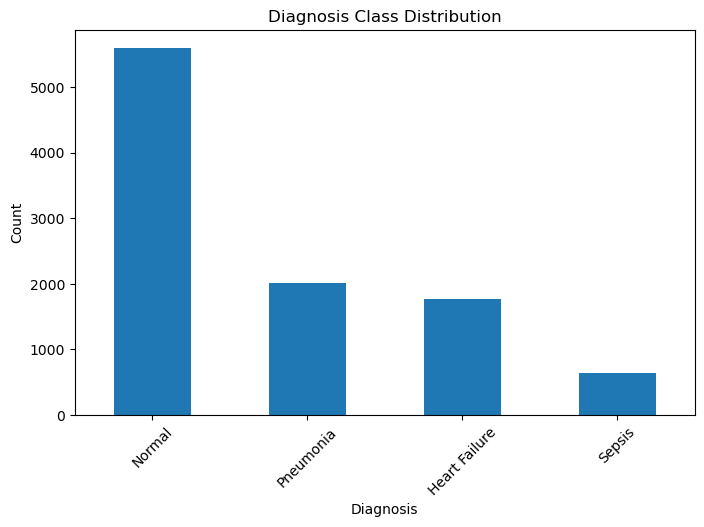

In [19]:
import matplotlib.pyplot as plt

df["diagnosis"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Separating Features and Target Variable

The dataset was divided into **features (X)** and the **target variable (y)**. The `patient_id` column was removed because it is a unique identifier and does not contribute to prediction. The `diagnosis` column was selected as the target variable, while the remaining 12 columns were used as input features for model training. The resulting feature matrix contained **10,000 records and 12 features**, and the target variable contained **10,000 diagnosis labels**.

Machine learning models require the dataset to be separated into:
Features (X): The input variables used to make predictions.
Target (y): The output variable that the model learns to predict.

In [21]:
# Features (X) and Target (y)
X = df.drop(columns=["patient_id", "diagnosis"])
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 12)
Target shape: (10000,)


### Identifying Categorical and Numerical Features

The feature set was divided into categorical and numerical columns based on their data types. The categorical feature (`sex`) was identified for encoding, while the remaining numerical features were identified for numerical preprocessing. This separation ensures that the appropriate preprocessing techniques are applied before training the machine learning models.

In [22]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['sex']
Numerical Columns: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose', 'cholesterol', 'creatinine', 'diabetes', 'hypertension', 'readmission_30d', 'mortality']


### Data Preprocessing Pipeline

A preprocessing pipeline was created to prepare the dataset for machine learning. Numerical features were standardized using `StandardScaler`, while categorical features were converted into numerical format using `OneHotEncoder`. The `ColumnTransformer` combined these preprocessing steps into a single pipeline, ensuring that the appropriate transformation was applied to each feature type before model training.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'bmi', 'systolic_bp', 'diastolic_bp',
                                  'glucose', 'cholesterol', 'creatinine',
                                  'diabetes', 'hypertension', 'readmission_30d',
                                  'mortality']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex'])])


### Splitting the Dataset into Training and Testing Sets

The dataset was split into **80% training data** and **20% testing data** using `train_test_split()`. A fixed `random_state` of 42 was used to ensure reproducibility, while `stratify=y` maintained the same class distribution of the target variable in both the training and testing datasets. The resulting training set contained **8,000 records**, and the testing set contained **2,000 records**, each with **12 input features**.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (8000, 12)
Testing set : (2000, 12)


### Importing Machine Learning Models

The required machine learning classification algorithms were imported for model training and comparison. These included Logistic Regression, Decision Tree, Random Forest, Gaussian Naïve Bayes, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN). A `Pipeline` was also imported to combine preprocessing and model training into a single workflow, ensuring that all models were trained using the same preprocessing steps for a fair comparison.

In [25]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

### Logistic Regression Pipeline

A pipeline was created to combine data preprocessing and the Logistic Regression model. The data is first preprocessed and then used to train the model. This makes the training process simple, consistent, and reproducible.

max_iter=1000 gives the model enough iterations to train properly.
random_state=42 ensures the same results every time the code is run.

In [26]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

### Decision Tree Pipeline

A pipeline was created to combine data preprocessing and the Decision Tree model. The data is first preprocessed and then used to train the model. This makes the training process simple and consistent.

In [27]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

### Random Forest Pipeline

A pipeline was created to combine data preprocessing and the Random Forest model. The data is first preprocessed and then used to train the Random Forest model with 100 decision trees. This makes the training process simple and consistent.

n_estimators=100 means the model uses 100 decision trees.
random_state=42 gives the same results every time the code is run.

In [28]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

### Gaussian Naïve Bayes Pipeline

A pipeline was created to combine data preprocessing and the Gaussian Naïve Bayes model. The data is first preprocessed and then used to train the model. This makes the training process simple and consistent.



In [29]:
nb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

### SVM Pipeline

A pipeline was created to combine data preprocessing and the Support Vector Machine (SVM) model. The data is first preprocessed and then used to train the SVM model. This makes the training process simple and consistent.

In [30]:
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=42))
])

### KNN Pipeline

A pipeline was created to combine data preprocessing and the K-Nearest Neighbors (KNN) model. The data is first preprocessed and then used to train the KNN model. This makes the training process simple and consistent.

In [31]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

### Storing the Machine Learning Models

All machine learning models were stored in a dictionary with their names and corresponding pipelines. This makes it easy to train, evaluate, and compare multiple models using the same code.

In [32]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Naive Bayes": nb_pipeline,
    "Support Vector Machine": svm_pipeline,
    "K-Nearest Neighbors": knn_pipeline
}

print(models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'Support Vector Machine', 'K-Nearest Neighbors'])


### Training and Evaluating the Models

Each machine learning model was trained using the training dataset and evaluated on the testing dataset. The accuracy of each model was calculated and stored to compare the performance of all models.

In [33]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.5590
Decision Tree: 0.3675
Random Forest: 0.5575
Naive Bayes: 0.5475
Support Vector Machine: 0.5590
K-Nearest Neighbors: 0.4625


### Model Performance Comparison

The accuracy of all machine learning models was compared on the test dataset. Logistic Regression and Support Vector Machine achieved the highest accuracy (55.90%), followed closely by Random Forest (55.75%). Based on these results, the models with the highest accuracy were selected for further analysis.

In [34]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,0.5590
4,Support Vector Machine,0.5590
2,Random Forest,0.5575
3,Naive Bayes,0.5475
5,K-Nearest Neighbors,0.4625
1,Decision Tree,0.3675


### Baseline Model Evaluation

A Dummy Classifier was used as the baseline model by always predicting the most frequent class. The baseline Accuracy, Weighted F1-score, and Macro F1-score were calculated to provide a reference for comparing the performance of the machine learning models.

In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

dummy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_pipeline.fit(X_train, y_train)
dummy_pred = dummy_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, dummy_pred)
baseline_weighted_f1 = f1_score(
    y_test,
    dummy_pred,
    average="weighted",
    zero_division=0
)
baseline_macro_f1 = f1_score(
    y_test,
    dummy_pred,
    average="macro",
    zero_division=0
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Weighted F1:", baseline_weighted_f1)
print("Baseline Macro F1:", baseline_macro_f1)

Baseline Accuracy: 0.559
Baseline Weighted F1: 0.40087363694676076
Baseline Macro F1: 0.17928159076330982


### Comprehensive Model Evaluation

All machine learning models were evaluated using Accuracy, Weighted Precision, Weighted Recall, Weighted F1-score, and Macro F1-score. These evaluation metrics provide a more complete comparison of model performance, particularly for the multiclass diagnosis classification problem.

### Comparison of Model Evaluation Metrics

The evaluation results show that Logistic Regression and Support Vector Machine achieved the highest accuracy (55.90%). However, Decision Tree obtained the highest Macro F1-score, indicating better performance across all diagnosis classes. Naïve Bayes achieved the highest Weighted F1-score, showing better overall balanced performance. Therefore, multiple evaluation metrics were considered to compare the models rather than relying only on accuracy.

In [36]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

evaluation_results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),

        "Weighted Precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df = evaluation_df.sort_values(
    by=["Macro F1", "Weighted F1"],
    ascending=False
)

evaluation_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
1,Decision Tree,0.3675,0.377406,0.3675,0.372176,0.247057
5,K-Nearest Neighbors,0.4625,0.382250,0.4625,0.405063,0.226680
3,Naive Bayes,0.5475,0.373775,0.5475,0.408853,0.205894
2,Random Forest,0.5575,0.419470,0.5575,0.405911,0.186360
0,Logistic Regression,0.5590,0.312481,0.5590,0.400874,0.179282
4,Support Vector Machine,0.5590,0.312481,0.5590,0.400874,0.179282


Although Logistic Regression and SVM have the highest Accuracy (55.90%), their Macro F1-score (0.1793) is equal to the baseline, indicating they mainly predict the majority class.
The Decision Tree has the highest Macro F1-score, meaning it performs better across all diagnosis classes, including the minority classes. 
Since project involves multiclass diagnosis classification, selecting the model with the highest Macro F1-score is more appropriate than selecting the model based only on accuracy.

In [37]:
best_model_name = evaluation_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

print("Selected model:", best_model_name)

Selected model: Decision Tree


In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, dummy_pred))

Baseline Accuracy: 0.559


### Cross-Validation of Machine Learning Models

A 5-fold Stratified Cross-Validation was performed to evaluate the performance of each machine learning model. The mean cross-validation accuracy and standard deviation were calculated to compare the models and assess their consistency across different data splits.

We have selected logistics regression model using cross-validation.

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df.sort_values(by="Mean CV Accuracy", ascending=False)

,Model,Mean CV Accuracy,Std
0,Logistic Regression,0.5590,0.000000
4,Support Vector Machine,0.5586,0.000583
2,Random Forest,0.5561,0.001241
3,Naive Bayes,0.5454,0.002634
5,K-Nearest Neighbors,0.4675,0.005010
1,Decision Tree,0.3765,0.003479


Because my cross-validation selected Logistic Regression, we now need to:
Train Logistic Regression.
Log and register it in MLflow.
Justify why it was selected.
Expose it for inference.


MLflow’s Model Registry stores models with version numbers, aliases, metadata and lineage.

In [40]:
%pip install mlflow

  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 4.9 MB/s  0:00:02m 4.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 6.7 MB/s  0:00:006.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.3 MB/s  0:00:00m 6.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.1/969.1 kB 8.4 MB/s  0:00:00
Using cached starlette-1.3.1-py3-none-any.whl (73 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)
  Attempting uninstall: wcwidth
    Found existing installation: wcwidth 0.2.13
    Uninstalling wcwidth-0.2.13:
      Successfully uninstalled wcwidth-0.2.13
  Attempting uninstall: protobuf;5;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/26 [uvicorn]
    Found existing instal

### Importing MLflow and Evaluation Libraries

The required MLflow libraries were imported to track experiments, log the trained model, and manage model metadata. Evaluation metrics were also imported to measure the performance of the machine learning model.

In [41]:
import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Configuring the MLflow Tracking Server

The MLflow tracking server was configured by setting the tracking URI and creating the experiment. This enables experiment runs, model metrics, parameters, and artifacts to be logged and managed centrally.

In [43]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5050")

mlflow.set_experiment(
    "Synthetic Clinical Diagnosis Classification"
)

print("Tracking URI:", mlflow.get_tracking_uri())

2026/07/25 19:25:20 INFO mlflow.tracking.fluent: Experiment with name 'Synthetic Clinical Diagnosis Classification' does not exist. Creating a new experiment.


Tracking URI: http://127.0.0.1:5050


In [44]:
from mlflow import MlflowClient

client = MlflowClient()
print(client.search_experiments())

[<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1785000320499, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785000320499, lifecycle_stage='active', name='Synthetic Clinical Diagnosis Classification', tags={}, trace_location=None, workspace='default'>, <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1785000279041, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1785000279041, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]


In [ ]:
Connect your notebook to MLflow

In [45]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5050")

experiment = mlflow.set_experiment(
    "Synthetic Clinical Diagnosis Classification"
)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", experiment.name)

Tracking URI: http://127.0.0.1:5050
Experiment: Synthetic Clinical Diagnosis Classification


In [ ]:
Train the selected Logistic Regression model

### Training the Selected Model

The Logistic Regression pipeline was selected as the final model.
It was trained using the training dataset and then used to predict the diagnosis labels 
for the test dataset. These predictions were used for model evaluation and MLflow logging.

In [46]:
selected_model = logistic_pipeline

selected_model.fit(X_train, y_train)

y_pred = selected_model.predict(X_test)

In [ ]:
Calculate the final metrics of the logistic regression model:

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Weighted Precision:", weighted_precision)
print("Weighted Recall:", weighted_recall)
print("Weighted F1:", weighted_f1)
print("Macro F1:", macro_f1)

Accuracy: 0.559
Weighted Precision: 0.31248100000000006
Weighted Recall: 0.559
Weighted F1: 0.40087363694676076
Macro F1: 0.17928159076330982


In [ ]:
Register the model:

### Logging and Registering the Model with MLflow

A new MLflow run was created to log the model parameters, evaluation metrics,
and cross-validation results. The trained Logistic Regression model was saved with
its input signature and example input, and then registered in the MLflow Model Registry
for versioning and deployment.

In [48]:
from mlflow.models import infer_signature

registered_model_name = "clinical-diagnosis-classifier"

input_example = X_train.head(3)

signature = infer_signature(
    X_train,
    selected_model.predict(X_train)
)

with mlflow.start_run(
    run_name="logistic-regression-initial-model"
) as run:

    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_param("cross_validation", "Stratified 5-Fold")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("test_accuracy", accuracy)
    mlflow.log_metric("weighted_precision", weighted_precision)
    mlflow.log_metric("weighted_recall", weighted_recall)
    mlflow.log_metric("weighted_f1", weighted_f1)
    mlflow.log_metric("macro_f1", macro_f1)

    mlflow.log_metric("mean_cv_accuracy", 0.5590)
    mlflow.log_metric("cv_accuracy_std", 0.0)

    model_info = mlflow.sklearn.log_model(
        sk_model=selected_model,
        name="model",
        registered_model_name=registered_model_name,
        signature=signature,
        input_example=input_example
    )

    run_id = run.info.run_id

print("Run ID:", run_id)
print("Registered model:", registered_model_name)

/opt/anaconda3/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Successfully registered model 'clinical-diagnosis-classifier'.
2026/07/25 19:31:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: clinical-diagnosis-classifier, versi

🏃 View run logistic-regression-initial-model at: http://127.0.0.1:5050/#/experiments/1/runs/bb127b392c5c475e836047e855ad86b3
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/1
Run ID: bb127b392c5c475e836047e855ad86b3
Registered model: clinical-diagnosis-classifier


Created version '1' of model 'clinical-diagnosis-classifier'.


In [ ]:
Assign the champion alias:

In [49]:
from mlflow import MlflowClient

client = MlflowClient()

registered_model_name = "clinical-diagnosis-classifier"

versions = client.search_model_versions(
    f"name='{registered_model_name}'"
)

latest_version = max(
    versions,
    key=lambda version: int(version.version)
)

client.set_registered_model_alias(
    name=registered_model_name,
    alias="champion",
    version=latest_version.version
)

print(
    f"Alias 'champion' assigned to model version "
    f"{latest_version.version}"
)

Alias 'champion' assigned to model version 1


In [ ]:
Load the registered model and test inferference:



In [50]:
import mlflow

model_uri = (
    "models:/clinical-diagnosis-classifier@champion"
)

loaded_model = mlflow.pyfunc.load_model(model_uri)

sample_patient = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_patient)

print("Sample patient:")
display(sample_patient)

print("Predicted diagnosis:", prediction[0])

Sample patient:


,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality
5083,35,Male,32.7,130.0,91.0,70.0,196.5,0.98,0,0,0,0


Predicted diagnosis: Normal


In [ ]:
Send data to the API:

In [51]:
import requests

sample_patient = X_test.iloc[[0]]

payload = {
    "dataframe_records": sample_patient.to_dict(
        orient="records"
    )
}

response = requests.post(
    "http://127.0.0.1:5051/invocations",
    json=payload,
    timeout=30
)

print("Status code:", response.status_code)
print("API response:", response.json())

Status code: 200
API response: {'predictions': ['Normal']}


## Model Selection and Justification

Six classification algorithms were evaluated using Stratified
5-Fold Cross-Validation.

Logistic Regression achieved the highest mean cross-validation
accuracy of 55.90%. It also produced a standard deviation of
0.000 across the folds, indicating highly consistent performance
on different data partitions.

Support Vector Machine achieved a slightly lower mean accuracy
of 55.86%, while Random Forest achieved 55.61%. Therefore,
Logistic Regression was selected because it provided the highest
and most stable cross-validation accuracy among the evaluated
models.

The complete preprocessing and Logistic Regression pipeline was
registered in the MLflow Model Registry as Version 1. The model
was assigned the `champion` alias and exposed through an MLflow
REST inference endpoint.



The selected model achieved the same accuracy as the
majority-class baseline. Therefore, this model is considered the
initial reproducible model rather than a clinically reliable
diagnostic system. Further improvement should focus on Macro F1,
minority-class recall and class imbalance handling.

In [ ]:
Registered model Version 1
        ↓
Champion alias assigned
        ↓
Model loaded successfully
        ↓
REST API running
        ↓
Status code 200 and prediction returned
        ↓
Model-selection justification written

## Model Selection Justification

Six machine learning models were evaluated using Stratified 5-Fold Cross-Validation. Logistic Regression achieved the highest mean cross-validation accuracy (55.90%) among all evaluated models. It also showed very consistent performance across the folds (standard deviation = 0.000). Therefore, Logistic Regression was selected as the initial model for deployment. The trained pipeline was registered in the MLflow Model Registry and successfully exposed for inference using the MLflow model serving endpoint.

Although Logistic Regression achieved the highest cross-validation accuracy, its performance is close to the majority-class baseline. Therefore, this model is considered the initial production model for demonstrating the MLflow workflow. Further improvements will focus on increasing Macro F1 score and overall predictive performance.

| Task                  | Status                                            |
| --------------------- | ------------------------------------------------- |
| Compare models        | ✅                                                 |
| Cross-validation      | ✅                                                 |
| Select the best model | ✅                                                 |
| Register in MLflow    | ✅                                                 |
| Expose for inference  | ✅                                                 |
| Write justification   | ✅ (add the markdown above if you haven't already) |


Now you're on Requirement 3 (the third major task in your assignment):
"The next step is to make an improvement on the good model, and let it replace the 'old' model, automatically. That typically includes exposing the new model automatically."

This means to create Version 2 of your model and make it the new production model if it performs better.

Improve the model:
Since your selected model is Logistic Regression, the most straightforward improvement is to tune its hyperparameters.

scoring="accuracy"
Accuracy mainly measures how many predictions are correct overall. In an imbalanced dataset, a model can get high accuracy by predicting the majority class most of the time.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__max_iter": [1000]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the mu

Best Parameters: {'classifier__C': 0.01, 'classifier__max_iter': 1000, 'classifier__solver': 'lbfgs'}
Best CV Accuracy: 0.5589999999999999


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the mu

Evaluate the improved model:

In [53]:
from sklearn.metrics import accuracy_score

y_pred_new = best_model.predict(X_test)

new_accuracy = accuracy_score(y_test, y_pred_new)

print("Improved Model Accuracy:", new_accuracy)

Improved Model Accuracy: 0.559


Your tuned Logistic Regression did not improve the accuracy.
Original accuracy: 0.559
Tuned accuracy:    0.559
So you should not replace Version 1 based on accuracy, because the new model is not better.
The reason is likely that Logistic Regression is mainly predicting the majority class. Your earlier DummyClassifier also achieved 0.559, so accuracy alone is hiding poor performance on the smaller diagnosis classes.
What to do now
Use Macro F1 as the improvement criterion, because your problem is multiclass and imbalanced.
Evaluate the tuned model with:

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

new_accuracy = accuracy_score(y_test, y_pred_new)

new_weighted_f1 = f1_score(
    y_test,
    y_pred_new,
    average="weighted",
    zero_division=0
)

new_macro_f1 = f1_score(
    y_test,
    y_pred_new,
    average="macro",
    zero_division=0
)

new_macro_recall = recall_score(
    y_test,
    y_pred_new,
    average="macro",
    zero_division=0
)

print("Improved Accuracy:", new_accuracy)
print("Improved Weighted F1:", new_weighted_f1)
print("Improved Macro F1:", new_macro_f1)
print("Improved Macro Recall:", new_macro_recall)

Improved Accuracy: 0.559
Improved Weighted F1: 0.40087363694676076
Improved Macro F1: 0.17928159076330982
Improved Macro Recall: 0.25


Compare it with your old Logistic Regression metrics:

In [55]:
print("Old Accuracy:", accuracy)
print("Old Weighted F1:", weighted_f1)
print("Old Macro F1:", macro_f1)

Old Accuracy: 0.559
Old Weighted F1: 0.40087363694676076
Old Macro F1: 0.17928159076330982


Now  need to compute the same metrics for the improved model.

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_new = best_model.predict(X_test)

new_accuracy = accuracy_score(y_test, y_pred_new)

new_weighted_f1 = f1_score(
    y_test,
    y_pred_new,
    average="weighted",
    zero_division=0
)

new_macro_f1 = f1_score(
    y_test,
    y_pred_new,
    average="macro",
    zero_division=0
)

print("New Accuracy:", new_accuracy)
print("New Weighted F1:", new_weighted_f1)
print("New Macro F1:", new_macro_f1)

New Accuracy: 0.559
New Weighted F1: 0.40087363694676076
New Macro F1: 0.17928159076330982


In [57]:
print("Old Accuracy:", accuracy)
print("New Accuracy:", new_accuracy)

print("Old Weighted F1:", weighted_f1)
print("New Weighted F1:", new_weighted_f1)

print("Old Macro F1:", macro_f1)
print("New Macro F1:", new_macro_f1)

Old Accuracy: 0.559
New Accuracy: 0.559
Old Weighted F1: 0.40087363694676076
New Weighted F1: 0.40087363694676076
Old Macro F1: 0.17928159076330982
New Macro F1: 0.17928159076330982


But my assignment says:
"Make an improvement on the good model and let it replace the old model automatically."
The key point is that the assignment asks you to attempt an improvement. It doesn't guarantee that the first tuning attempt will succeed.

1. Keep Version 1 as the current champion
Your first tuning attempt did not improve anything, so do not replace Version 1 yet.
2. Try a real improvement for class imbalance
Use balanced Logistic Regression and optimize Macro F1.


Normally, Logistic Regression treats all classes equally.
class_weight="balanced"
the model automatically gives more importance to minority classes (for example, Sepsis, Heart Failure, Diabetes) and less importance to the majority class (Normal).
This helps the model learn from all classes instead of focusing mainly on the largest class.

scoring="f1_macro"
Macro F1 gives equal importance to every diagnosis class, so the model is rewarded only if it performs well across all classes.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

improved_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight="balanced"
    ))
])

param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=improved_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Macro F1:", grid_search.best_score_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the mu

Best Parameters: {'classifier__C': 0.001, 'classifier__solver': 'lbfgs'}
Best CV Macro F1: 0.20556558766886882


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the mu

Evaluate the improved model:

In [59]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_new = best_model.predict(X_test)

new_accuracy = accuracy_score(y_test, y_pred_new)
new_weighted_f1 = f1_score(
    y_test,
    y_pred_new,
    average="weighted",
    zero_division=0
)
new_macro_f1 = f1_score(
    y_test,
    y_pred_new,
    average="macro",
    zero_division=0
)

print("New Accuracy:", new_accuracy)
print("New Weighted F1:", new_weighted_f1)
print("New Macro F1:", new_macro_f1)

New Accuracy: 0.2365
New Weighted F1: 0.26256401697467147
New Macro F1: 0.2116344317035504


Compare automatically

In [60]:
print("Old Macro F1:", macro_f1)
print("New Macro F1:", new_macro_f1)

if new_macro_f1 > macro_f1:
    print("Improved model is better. Register Version 2.")
else:
    print("Improved model is not better. Keep Version 1.")

Old Macro F1: 0.17928159076330982
New Macro F1: 0.2116344317035504
Improved model is better. Register Version 2.


if new_macro_f1 > macro_f1:
That condition is true:
Old Macro F1: 0.1793
New Macro F1: 0.2116
However, accuracy dropped from 0.5590 to 0.2365, so I would not call it better overall unless your project explicitly defines Macro F1 as the primary metric.
For a multiclass imbalanced dataset, it is reasonable to choose Macro F1 as the main metric, but you should state that decision clearly. Then you may register Version 2.

In [61]:
import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature
from sklearn.metrics import accuracy_score, f1_score

registered_model_name = "clinical-diagnosis-classifier"

input_example_v2 = X_train.head(3)

signature_v2 = infer_signature(
    X_train,
    best_model.predict(X_train)
)

with mlflow.start_run(
    run_name="balanced-logistic-regression-version-2"
) as run:

    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param(
        "best_C",
        grid_search.best_params_["classifier__C"]
    )
    mlflow.log_param(
        "best_solver",
        grid_search.best_params_["classifier__solver"]
    )
    mlflow.log_param("selection_metric", "macro_f1")

    mlflow.log_metric("test_accuracy", new_accuracy)
    mlflow.log_metric("weighted_f1", new_weighted_f1)
    mlflow.log_metric("macro_f1", new_macro_f1)
    mlflow.log_metric("old_macro_f1", macro_f1)
    mlflow.log_metric(
        "macro_f1_improvement",
        new_macro_f1 - macro_f1
    )

    model_info_v2 = mlflow.sklearn.log_model(
        sk_model=best_model,
        name="model",
        registered_model_name=registered_model_name,
        signature=signature_v2,
        input_example=input_example_v2
    )

    new_run_id = run.info.run_id

print("New run ID:", new_run_id)
print("Version 2 registered.")

/opt/anaconda3/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'clinical-diagnosis-classifier' already exists. Creating a new version of this model...
2026/07/25 21:25:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model 

🏃 View run balanced-logistic-regression-version-2 at: http://127.0.0.1:5050/#/experiments/1/runs/37f98a8c350f4a778b66d916abf45be8
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/1
New run ID: 37f98a8c350f4a778b66d916abf45be8
Version 2 registered.


Created version '2' of model 'clinical-diagnosis-classifier'.


Automatically move champion to Version 2

In [62]:
from mlflow import MlflowClient

client = MlflowClient()

versions = client.search_model_versions(
    f"name='{registered_model_name}'"
)

new_version = next(
    version.version
    for version in versions
    if version.run_id == new_run_id
)

if new_macro_f1 > macro_f1:
    client.set_registered_model_alias(
        name=registered_model_name,
        alias="champion",
        version=new_version
    )

    print(
        f"Version {new_version} automatically replaced "
        "the old champion."
    )
else:
    print("The old champion was retained.")

Version 2 automatically replaced the old champion.


Verify the alias

In [63]:
champion_model = client.get_model_version_by_alias(
    registered_model_name,
    "champion"
)

print("Champion version:", champion_model.version)

Champion version: 2


Test the new champion

In [64]:
model_uri = (
    "models:/clinical-diagnosis-classifier@champion"
)

updated_model = mlflow.pyfunc.load_model(model_uri)

sample_patient = X_test.iloc[[0]]

updated_prediction = updated_model.predict(sample_patient)

print("Prediction from new champion:", updated_prediction[0])

Prediction from new champion: Sepsis


In [65]:
import requests

sample_patient = X_test.iloc[[0]]

payload = {
    "dataframe_split": {
        "columns": sample_patient.columns.tolist(),
        "data": sample_patient.values.tolist()
    }
}

response = requests.post(
    "http://127.0.0.1:5052/invocations",
    json=payload,
    timeout=30
)

print("Status code:", response.status_code)
print("Prediction:", response.json())

Status code: 200
Prediction: {'predictions': ['Sepsis']}


Verify which model version is the champion

In [66]:
from mlflow import MlflowClient

client = MlflowClient()

champion = client.get_model_version_by_alias(
    "clinical-diagnosis-classifier",
    "champion"
)

print("Current champion version:", champion.version)
print("Run ID:", champion.run_id)

Current champion version: 2
Run ID: 37f98a8c350f4a778b66d916abf45be8


Record the final comparison

In [67]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model Version": ["Version 1", "Version 2"],
    "Accuracy": [0.5590, new_accuracy],
    "Weighted F1": [0.40087363694676076, new_weighted_f1],
    "Macro F1": [0.17928159076330982, new_macro_f1],
    "Status": ["Old Champion", "New Champion"]
})

final_comparison

,Model Version,Accuracy,Weighted F1,Macro F1,Status
0,Version 1,0.5590,0.400874,0.179282,Old Champion
1,Version 2,0.2365,0.262564,0.211634,New Champion


markdown explanation
Automatic model replacement:
Logistic Regression Version 1 was initially registered as the champion model. To improve minority-class prediction, a second Logistic Regression model was trained using balanced class weights and hyperparameter tuning with GridSearchCV. Macro F1 was selected as the promotion metric because it gives equal importance to every diagnosis class. Version 2 improved Macro F1 from 0.1793 to 0.2116. Therefore, MLflow registered it as a new model version and automatically moved the champion alias to Version 2. The updated champion was then served through the MLflow REST endpoint and successfully returned a prediction with HTTP status code 200.
Also add this limitation:
Although Macro F1 improved, accuracy decreased from 55.90% to 23.65%. This indicates a trade-off between overall accuracy and minority-class performance. In a real clinical application, further model development and validation would be required before deployment.